# 02 · Rheometers and their pitfalls

A rheometer measures a **torque and a rotation speed** (rotational instruments) or a **pressure drop and a
flow rate** (capillaries). Converting them to shear stress and shear rate needs a geometry formula - and
the simple formulas assume a Newtonian fluid, no slip at the walls, and no end effects. This notebook
shows when those assumptions fail, by how much, and how to correct for it.

**What you will learn**
- convert torque and speed (or pressure and flow rate) into stress and shear rate
- apply the Weissenberg-Rabinowitsch, Bagley and Mooney corrections
- recognise partially sheared gaps, wall slip and instrument limits

**Before you start:** notebooks 00-01  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, fitting, geometry, models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Cone-plate: the reference geometry
A small cone angle makes the shear rate the same everywhere in the gap, so $\tau = 3M/(2\pi R^3)$ and
$\dot\gamma = \Omega/\theta$ hold for any fluid. Parallel plates are easier to load, but the shear rate grows from
zero at the centre to its maximum at the rim, and the simple (Newtonian) stress formula becomes wrong for
shear-thinning fluids:

In [2]:
R, h = 0.025, 1e-3
omega = np.logspace(-2, 2, 25)
rate_R = omega * R / h
K, n = 2.0, 0.45                                    # a shear-thinning fluid
M = 2 * np.pi * K * rate_R**n * R**3 / (n + 3)      # exact torque for a power-law fluid between plates
tau_newt, _, _ = geometry.parallel_plate(M, omega, R, h, correct=False)
tau_corr, _, n_est = geometry.parallel_plate(M, omega, R, h)
print(f"Newtonian formula overestimates the rim stress by {np.mean(tau_newt/(K*rate_R**n)) - 1:.1%}")
print(f"corrected (Weissenberg-Rabinowitsch type) formula: max error {np.max(np.abs(tau_corr/(K*rate_R**n) - 1)):.1e}")

Newtonian formula overestimates the rim stress by 15.9%
corrected (Weissenberg-Rabinowitsch type) formula: max error 8.9e-16


## Couette cells and yield-stress fluids
In a concentric-cylinder (Couette) cell the stress falls as $1/r^2$ across the gap. For a yield-stress fluid
at low speeds, the stress near the outer cylinder can fall *below* the yield stress: only part of the gap
flows, and the usual conversion formulas no longer apply.

In [3]:
Rb, Rr, L = 0.017245, 0.018415, 0.038                # Fann 35 bob and rotor (drilling-fluid viscometer)
from scipy import optimize
ty, mup = 5.0, 0.03                                 # a Bingham fluid (a drilling-mud-like yield stress)
M_yield = 2 * np.pi * Rb**2 * L * ty                 # below this torque nothing flows
for rpm in (3, 6, 100, 600):
    omega_ = rpm * 2 * np.pi / 60
    M_ = optimize.brentq(lambda m: geometry.couette_speed("bingham", (ty, mup), m, Rb, Rr, L) - omega_, M_yield * 1.0000001, 1.0)
    r_c = min(Rr, np.sqrt(M_ / (2 * np.pi * L * ty)))   # radius where the stress falls to the yield stress
    print(f"{rpm:4d} rpm: torque {M_*1e3:6.3f} mN m, sheared fraction of the gap {(r_c - Rb)/(Rr - Rb):6.1%}")

   3 rpm: torque  0.387 mN m, sheared fraction of the gap  64.4%
   6 rpm: torque  0.400 mN m, sheared fraction of the gap  91.4%
 100 rpm: torque  0.741 mN m, sheared fraction of the gap 100.0%
 600 rpm: torque  2.555 mN m, sheared fraction of the gap 100.0%


At the low speeds used to estimate yield stresses - the 3 and 6 rpm readings of drilling-fluid viscometers -
only part of the gap is sheared, so the standard conversion (which assumes the whole gap flows) does not
apply to exactly the readings used for the yield stress. This is one reason why field "yield points"
differ from true yield stresses (notebook 04).

## Capillary rheometers: two corrections
A capillary rheometer pushes a melt through a die and records the pressure drop. Two corrections turn the
raw data into a flow curve:

1. **Bagley:** part of the pressure is lost entering the die. With several die lengths at the same flow rate,
   $\Delta P = 2\tau_w (L/R) + \Delta P_{ends}$ - a straight line in $L/R$ whose slope gives the true wall stress.
2. **Weissenberg-Rabinowitsch:** the apparent shear rate $4Q/(\pi R^3)$ assumes a parabolic (Newtonian) profile;
   for shear-thinning fluids the true wall rate is higher by $(3n' + 1)/(4n')$.

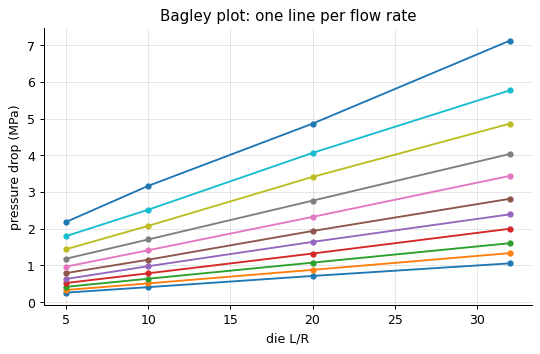

Bagley end correction e from 3.8 to 7.2 die radii (grows with the rate)
local power-law index n' from 0.28 to 0.40


In [4]:
melt = pd.read_csv(datasets.path("polymer_melt_capillary.csv"), comment="#")
melt["L_over_R"] = melt.die_length_mm / melt.die_radius_mm
Rd = melt.die_radius_mm.iloc[0] * 1e-3
tau_w, e_bag, app = [], [], []
fig, ax = plt.subplots()
for Q, grp in melt.groupby("flow_rate_m3_s"):
    b = geometry.bagley(grp.L_over_R, grp.pressure_drop_Pa)
    tau_w.append(b["tau_w"]); e_bag.append(b["e"]); app.append(4 * Q / (np.pi * Rd**3))
    ax.plot(grp.L_over_R, grp.pressure_drop_Pa / 1e6, "o-", ms=4)
ax.set(xlabel="die L/R", ylabel="pressure drop (MPa)", title="Bagley plot: one line per flow rate"); plt.show()
tau_w, app = np.array(tau_w), np.array(app)
print(f"Bagley end correction e from {min(e_bag):.1f} to {max(e_bag):.1f} die radii (grows with the rate)")
_, rate_w, n_prime = geometry.capillary(2 * tau_w, app * np.pi * Rd**3 / 4, R=Rd, L=Rd)   # tau_w already corrected
print(f"local power-law index n' from {n_prime.min():.2f} to {n_prime.max():.2f}")

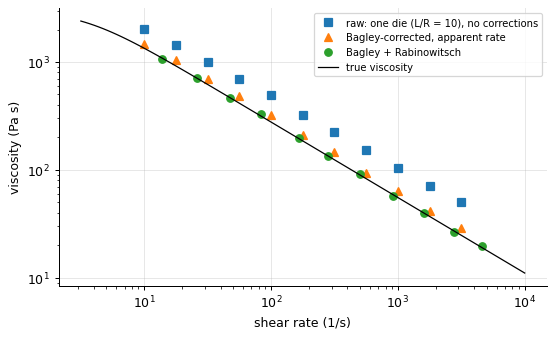

raw single-die viscosity / true viscosity at the same nominal rate: 1.52 to 2.03


In [5]:
single = melt[melt.L_over_R == 10]
tau_app_raw = single.pressure_drop_Pa * Rd / (2 * 10 * Rd)          # one die, no corrections
true_rate = np.logspace(0.5, 4, 100)
plt.loglog(4 * single.flow_rate_m3_s / (np.pi * Rd**3), tau_app_raw / (4 * single.flow_rate_m3_s / (np.pi * Rd**3)),
           "s", label="raw: one die (L/R = 10), no corrections")
plt.loglog(app, tau_w / app, "^", label="Bagley-corrected, apparent rate")
plt.loglog(rate_w, tau_w / rate_w, "o", label="Bagley + Rabinowitsch")
plt.loglog(true_rate, models.viscosity("carreau", true_rate, 3000.0, 0.0, 0.3, 0.3), "k-", lw=1, label="true viscosity")
plt.xlabel("shear rate (1/s)"); plt.ylabel("viscosity (Pa s)"); plt.legend(fontsize=8); plt.show()
raw_eta = (tau_app_raw / (4 * single.flow_rate_m3_s / (np.pi * Rd**3))).to_numpy()
raw_rate = (4 * single.flow_rate_m3_s / (np.pi * Rd**3)).to_numpy()
print(f"raw single-die viscosity / true viscosity at the same nominal rate: "
      f"{np.min(raw_eta / models.viscosity('carreau', raw_rate, 3000.0, 0.0, 0.3, 0.3)):.2f} to "
      f"{np.max(raw_eta / models.viscosity('carreau', raw_rate, 3000.0, 0.0, 0.3, 0.3)):.2f}")

Uncorrected, a single die overestimates the viscosity because the entrance pressure loss is counted as
if it were friction in the die; the Bagley correction removes that, and the Rabinowitsch correction then
moves each point to its true shear rate. (The file is synthetic, generated from a known melt, which is how
the "true" curve can be drawn.)

## Wall slip
Pastes, suspensions and gels often slip at smooth walls: a thin, particle-depleted layer lubricates the
surface. The hallmark: **the measured flow curve depends on the gap**.

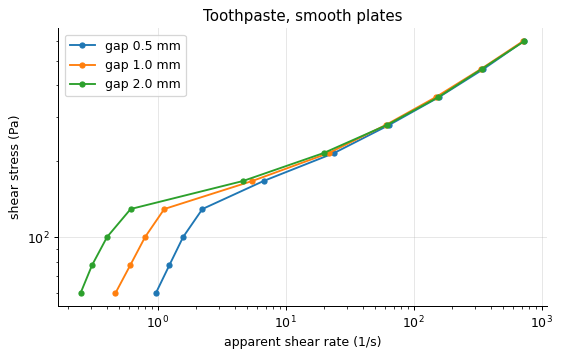

 stress_Pa  slip_free_rate_1_s  slip_velocity_mm_s  true_slip_mm_s  slip_share_at_0.5mm
      60.0              -0.000               0.241           0.240                0.991
      77.5              -0.005               0.310           0.310                1.003
     100.1               0.011               0.393           0.400                1.013
     129.3               0.060               0.543           0.517                0.925
     167.0               4.017               0.682           0.668                0.398
     215.6              18.679               1.326           0.862                0.145
     278.5              59.816               0.965           1.114                0.069
     359.7             152.015               1.059           1.439                0.036
     464.6             331.950               4.337           1.858                0.021
     600.0             729.200              -1.566           2.400                0.013


In [6]:
paste = pd.read_csv(datasets.path("toothpaste_plates_slip.csv"), comment="#")
for gap, grp in paste.groupby("gap_mm"):
    plt.loglog(grp.apparent_shear_rate_1_s, grp.shear_stress_Pa, "o-", ms=4, label=f"gap {gap} mm")
plt.xlabel("apparent shear rate (1/s)"); plt.ylabel("shear stress (Pa)"); plt.legend(); plt.title("Toothpaste, smooth plates")
plt.show()
rows = []
for stress, grp in paste.groupby("shear_stress_Pa"):
    m = geometry.mooney(grp.gap_mm * 1e-3, grp.apparent_shear_rate_1_s, kind="plates")
    true_slip = 4e-6 * stress * 1e3                   # the slip law used to generate the file (mm/s)
    share = 2 * true_slip * 1e-3 / 0.5e-3 / grp.apparent_shear_rate_1_s.iloc[0]
    rows.append((stress, m["true_rate"], m["slip_velocity"] * 1e3, true_slip, share))
res = pd.DataFrame(rows, columns=["stress_Pa", "slip_free_rate_1_s", "slip_velocity_mm_s", "true_slip_mm_s",
                                  "slip_share_at_0.5mm"])
print(res.round(3).to_string(index=False))

The Mooney analysis separates the true (slip-free) shear rate from the slip velocity at each stress. Below
the yield stress the true rate is essentially zero - the paste does not flow; it only slides on the plates.
Without the correction, that slip looks like flow, and the yield stress is missed.

The comparison with the true slip velocities (known here because the file is synthetic) shows the method's
limit: it is accurate where slip makes up a large share of the apparent rate (low stresses), but at high
stresses slip contributes only 1-2 % of the measured rate - no more than the 2 % measurement scatter - and
the estimates become meaningless, even negative. A Mooney analysis needs slip to be a substantial part of
the signal. In practice slip is prevented with roughened or serrated plates, and checked by testing at two
gaps.

## Instrument limits
Every measurement has a window: too little torque and the signal drowns in noise and friction; too
much speed and inertia or secondary flows (Taylor vortices in Couette cells) add to the torque.

In [7]:
M_min = 1e-7                                         # N m, a typical minimum for a good rotational rheometer
for name, (Rg, thg) in {"cone 50 mm / 1 deg": (0.025, np.radians(1)), "cone 25 mm / 1 deg": (0.0125, np.radians(1))}.items():
    tau_min, _ = geometry.cone_plate(M_min, 1.0, Rg, thg)
    print(f"{name}: lowest stress {tau_min*1e3:.2f} mPa -> lowest viscosity at 1 1/s {tau_min*1e3:.2f} mPa s, at 0.01 1/s {tau_min/0.01*1e3:.0f} mPa s")

cone 50 mm / 1 deg: lowest stress 3.06 mPa -> lowest viscosity at 1 1/s 3.06 mPa s, at 0.01 1/s 306 mPa s
cone 25 mm / 1 deg: lowest stress 24.45 mPa -> lowest viscosity at 1 1/s 24.45 mPa s, at 0.01 1/s 2445 mPa s


A larger geometry lowers the minimum measurable stress by the cube of the radius ratio. Low-viscosity
fluids at low shear rates are therefore measured with large cones or double-gap cylinders; data below the
low-torque limit should be discarded, not fitted.

## Inside the algorithm: the Weissenberg-Rabinowitsch correction
From the Bagley-corrected wall stresses and apparent rates, the local slope $n' = d\ln\tau_w/d\ln\dot\gamma_a$ gives the
true wall rate $\dot\gamma_w = \dot\gamma_a(3n' + 1)/(4n')$:

In [8]:
order = np.argsort(app)
n_hand = np.gradient(np.log(tau_w[order]), np.log(app[order]))
rate_hand = app[order] * (3 * n_hand + 1) / (4 * n_hand)
print("max difference from geometry.capillary:", np.max(np.abs(rate_hand / rate_w[order] - 1)))

max difference from geometry.capillary: 3.1086244689504383e-15


## Exercises
1. Fit a Carreau model to the melt data three ways - raw single-die data, Bagley-corrected data at the apparent rate, and fully corrected data - and compare $\eta_0$ and $n$ with the true values (3000 Pa·s, 0.3).
2. Taylor vortices appear in a Couette cell when $Ta = \Omega^2 R_i (R_o - R_i)^3 / \nu^2$ exceeds about 1700. At what rotation speed does this happen for water in a cell with $R_i$ = 12.5 mm, $R_o$ = 13.6 mm, and what shear rate does that correspond to?
3. **Implement it yourself:** do the Mooney analysis for one stress level of the toothpaste data by hand (straight-line fit of apparent rate against 1/gap) and compare with `geometry.mooney`.